In [28]:
%load_ext autoreload
%autoreload 2
import pickle
import numpy as np
import torch
import matplotlib.pyplot as plt
from YParams import YParams
from data_utils.data_loaders import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
mesh = np.loadtxt('../Data/test_data/mesh.csv', delimiter=',')

In [7]:
params = YParams('./config/ssl_ns_elastic.yaml', 'codano_test', print_params=False)

In [29]:
dataset = NsElasticDataset(params.data_location)
params.dt = 100
train, test = dataset.get_dataloader(params.mu_list, params.dt, ntrain=params.get(
        'ntrain'), ntest=params.get('ntest'), sample_per_inlet=params.sample_per_inlet)

Means:  None
stds  None
../Data/NS_ES/mu=1/i1=-0.5/i2=-0.5/i3=-0.1/Visualization/displacement.h5
Loaded tensor Size: torch.Size([1001, 1317, 3])
Loaded tensor Size: torch.Size([1001, 1317, 1])
Loaded tensor Size: torch.Size([1001, 1317, 3])
../Data/NS_ES/mu=1/i1=-0.5/i2=-0.5/i3=0/Visualization/displacement.h5
Loaded tensor Size: torch.Size([1001, 1317, 3])
Loaded tensor Size: torch.Size([1001, 1317, 1])
Loaded tensor Size: torch.Size([1001, 1317, 3])
../Data/NS_ES/mu=1/i1=-0.5/i2=-0.5/i3=0.05/Visualization/displacement.h5
Loaded tensor Size: torch.Size([1001, 1317, 3])
Loaded tensor Size: torch.Size([1001, 1317, 1])
Loaded tensor Size: torch.Size([1001, 1317, 3])
../Data/NS_ES/mu=1/i1=-0.5/i2=0/i3=-0.1/Visualization/displacement.h5
Loaded tensor Size: torch.Size([1001, 1317, 3])
Loaded tensor Size: torch.Size([1001, 1317, 1])
Loaded tensor Size: torch.Size([1001, 1317, 3])
../Data/NS_ES/mu=1/i1=-0.5/i2=0/i3=0/Visualization/displacement.h5
Loaded tensor Size: torch.Size([1001, 1317, 3])

In [10]:
mesh = torch.from_numpy(mesh).float()

tensor(-1.4248e-05) tensor(-1.6085e-07)


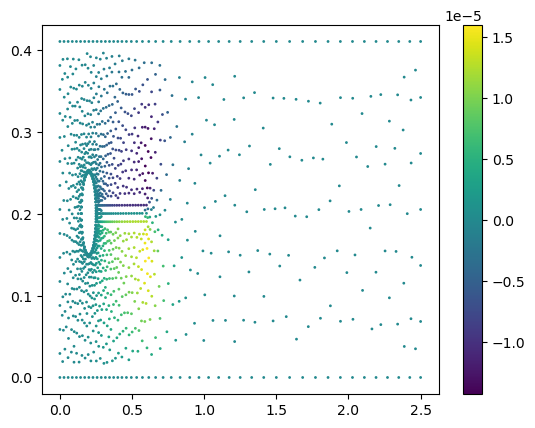

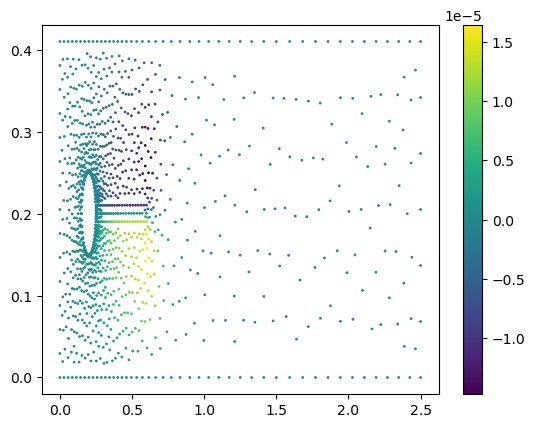

In [27]:
for data in test:
    x, y = data['x'], data['y']
    dx_mesh = data['d_grid_x'][0]
    dy_mesh = data['d_grid_y'][0]
    #print(mesh.shape, dx_mesh.shape, dy_mesh.shape, x.shape,y.shape)
    print(torch.min(dx_mesh[:,0]), torch.min(dx_mesh[:,1]))
    plt.scatter(mesh[0,:]+dx_mesh[:,0], mesh[1:]+dx_mesh[:,1],c=dx_mesh[:,0], cmap='viridis', s=1.0)
    plt.colorbar()
    plt.show()
    plt.scatter(mesh[0,:]+dy_mesh[:,0], mesh[1:]+dy_mesh[:,1],c=y[0,:,-2], cmap='viridis', s=1.0)
    plt.colorbar()
    plt.show()

In [26]:
_, mask = masker((1317, 7),max_block=0.7, drop_pix=0.3,\
                 channel_aug_rate = 0.8, channel_drop_rate = 0.4, device='cuda', min_block=10, max_blocks=100 )

In [27]:
mask[:,1]

tensor([0., 0., 0.,  ..., 0., 0., 0.], device='cuda:0')

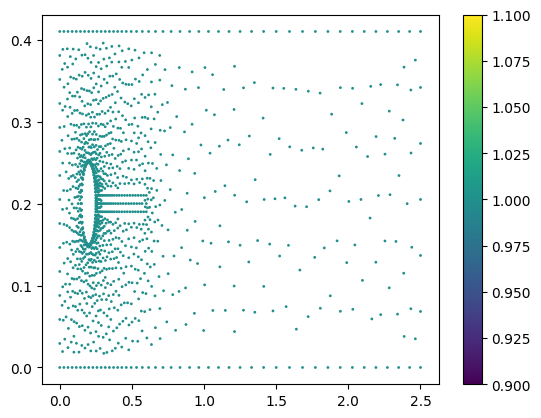

In [28]:
plt.scatter(mesh[0,:], mesh[1:],c=mask[:,4].cpu(), cmap='viridis', s=1.0)
plt.colorbar()

In [29]:
f

tensor([0.0000, 0.1681, 6.4181,  ..., 0.1098, 0.1204, 0.1166])

In [30]:
f[masker.in_nbr[-1].long()==1] = 0